# Trabajo Práctico número 2

Integrantes
- Gaspar Acevedo Zain (acevedo.zain.gaspar@gmail.com)

## Carga de utilities

In [54]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import Tuple
%matplotlib inline

In [23]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from utilities.image_quality import ImageQuality, QualityMeasure

In [24]:
video_path = '../../Material_TPs/TP2/focus_video.mov'

In [103]:
imageQuality = ImageQuality()

## Enunciado

***Objetivo***

Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" y realizar tres experimentos:
    1. Medición sobre todo el frame.
    1. Medición sobre una ROI ubicada en el centro del frame.  Area de la ROI = 5 o 10% del area total del frame.
    1. Opcional:
        1. Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc ... (al menos 3) 
    - Para cada experimento se debe presentar :
        - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto de máximo enfoque.
2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure 
operators in shapefrom focus.
    -   El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

***Puntos extra***: Aplicar unsharp masking para expandir la zona de enfoque y recalcular la métrica.

## Funciones generales

In [48]:
def obtener_métricas_de_video(path:str, measure: QualityMeasure = QualityMeasure.IMAGE_SHARPNESS_MEASURE,
                              roiPercentage:float=1.0) -> Tuple[pd.DataFrame, int, float, cv.typing.MatLike]:
    """
    Lee un video y obtiene calcula una métrica de enfoque en cada frame.

    Args:
        path (str): Path al video.
        measure (QualityMeasure): algoritmo a aplicar para calcular la métrica de calidad.
            Default: IMAGE_SHARPNESS_MEASURE (ver paper `Image Sharpness Measure for Blurred Images
            in Frequency Domain`).
        roiPercentage (float): Porcentage de área de interés (ROI), ubicada en el centro del frame.
            Default: 1.0 (no aplica ROI).
    Returns:
        Tupla:
            pd.DataFrame con columnas que representan los frames y sus respectivas métricas.
            int: Frame en donde se obtuvo el valor de máximo enfoque.
            float: Valor del máximo enfoque obtenido.
            cv.typing.MatLike: Frame con mejor métrica de enfoque.
    Raises:
        IOError: si no se puede abrir el video.
    """
    captura_video = cv.VideoCapture(path)

    imageQuality = ImageQuality()
    results = pd.DataFrame(columns=["Frame", measure.name])

    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
        raise IOError(f"Error al abrir el archivo de video")
    else:
        frame_numero = 0
        best_quality_value = -np.inf
        best_frame = None
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break

            iqm = imageQuality.imageQualityMeasure(image=frame,
                                                   roiPercentage=roiPercentage,
                                                   measure=measure)
            results.loc[len(results)] = [frame_numero, iqm]
            frame_numero = frame_numero + 1

            # Definimos cual es la mejor métrica y el mejor frame
            if iqm > best_quality_value:
                best_quality_value = iqm
                best_frame = frame

    captura_video.release()
    
    
    max_enfoque_idx = results[measure.name].idxmax()

    max_enfoque_value = results.loc[max_enfoque_idx, measure.name]
    max_enfoque_frame = results.loc[max_enfoque_idx, "Frame"]

    return results, max_enfoque_frame, max_enfoque_value, best_frame

In [49]:
def graficar_metricas_por_frames(data: pd.DataFrame, x: int, y: float, title: str):
    """
    Grafica un dataframe que contiene números de frames y sus respectivas métricas de enfoque.

    Args:
        data (pd.DataFrame): DataFrame con los datos a graficar.
        x (int): Frame con el valor de máximo enfoque.
        y (float): Métrica de máximo enfoque.
        title (str): Título
    """
    plt.scatter(data.iloc[:,0], data.iloc[:,1])
    plt.scatter(x, y, c="red", marker="D", label=f"{(int(x), float(np.round(y, 4)))}")
    plt.title(title)
    plt.xlabel(data.columns[0])
    plt.ylabel(data.columns[1])
    plt.legend(loc='upper left', title="Máximo Enfoque", ncol=1, fontsize='small', frameon=True, shadow=True)

## Punto 1

### Métrica - Image Sharpness Measure - Sin ROI

El algoritmo propuesto por el paper `Image Sharpness Measure for Blurred Images in Frequency Domain` está implementando en el método `imageSharpnessMeasure` de la clase `ImageQuality` (ver [utilities/image_quality.py](../utilities/image_quality.py)) y se define como:

*Input*: una imagen $I$.

- *Paso 1*: Computar $F$ o la representación de la transformada de Fourier de la imagen $I$.
- *Paso 2*: Encontrar $Fc$ que se obtiene desplazando el origen de $F$ al centro.
- *Paso 3*: Calcular $AF = abs (Fc)$, donde $AF$ es el valor absoluto de la transformada de Fourier centrada de la imagen $I$.
- *Paso 4*: Calcular $M = max (AF)$, donde $M$ es el valor donde $M$ es el valor máximo del componente de frecuencia en $F$.
- *Paso 5*: Calcular $TH$, que representa el total de pixeles de $F$ donde el valor del pixel es mayor a $thres = M/1000$.
- *Paso 6*: Calcular la métrica de calidad de Imagen (FM) a partir de la ecuación $TH/(MxN)$.

*Output*: métrica de calidad.

A continuación se procesa el video utilizando la métrica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`, trabajando sobre todo el frame (sin ROI).

El frame con mayor métrica de enfoque fue el número $91$, con un valor de mértica de $0.1038$.

El tiempo de ejecución fue de $30.4$ segundos.

| Métrica | ROI% | Mejor Frame | Mejor valor métrica | Tiempo ejecución |
| --- | --- | --- | --- | --- |
| `Image Sharpness` | - | $91$ | $0.1038$ | $30.4$ segundos |

In [50]:
ims_roi_100_df, ims_roi_100_max_frame, ims_roi_100_max_measure, ms_roi_100_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, measure=QualityMeasure.IMAGE_SHARPNESS_MEASURE)

A continuación grafica la evolución de la métrica de enfoque frame a frame. En rojo se resalta el punto de máximo enfoque.

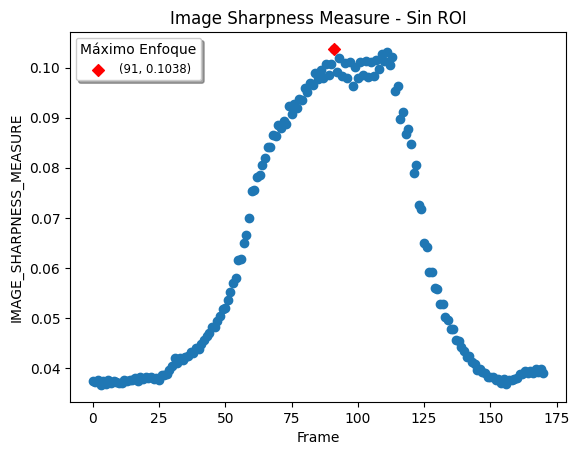

In [51]:
graficar_metricas_por_frames(ims_roi_100_df, x=ims_roi_100_max_frame, y=ims_roi_100_max_measure, title="Image Sharpness Measure - Sin ROI")

A continuación se muestra el frame donde se obtuvo la mejor métrica de enfoque

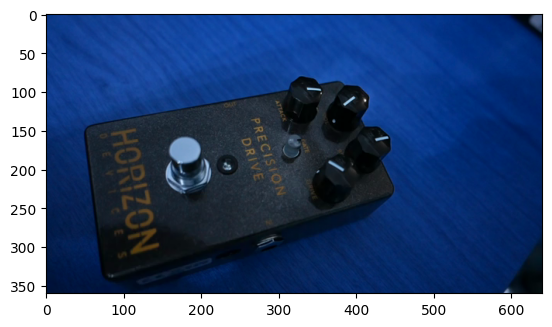

In [55]:
plt.imshow(ms_roi_100_frame)

### Métrica - Image Sharpness Measure - ROI 5%

A continuación se procesa el video utilizando la métrica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`, trabajando sobre todo el frame (sin ROI).

El frame con mayor métrica de enfoque fue el número $101$, con un valor de mértica de $0.5139$.

Si bien al graficar este frame se observa que el mismo está enfocado, notamos que la *métrica* obtenida es mayor que aquella obtenida al NO utilizar ROI, pero al graficar el ROI utilizado notamos que este está desenfocado.

Es decir, en este caso particular al reducir la imagen a un ROI de $5\%$ se obtuvo un buen resultado, pero no podría suceder lo mismo en otros casos, ya se usando ROI distintos, o distintos videos.

Otro detalle a mencionar es que el tiempo de ejecución pasa de $30.4$ segundos a $0.7$ segundos.

| Métrica | ROI% | Mejor Frame | Mejor valor métrica | Tiempo de ejecución |
| --- | --- | --- | --- | --- |
| `Image Sharpness` | - | $91$ | $0.1038$ | $0.7$ segundos |
| `Image Sharpness` | $5\%$ | $101$ | $0.5139$ | $30.4$ segundos |

In [77]:
ims_roi_5_df, ims_roi_5_max_frame, ims_roi_5_max_measure, ms_roi_5_frame = obtener_métricas_de_video(path=video_path, roiPercentage=0.05, measure=QualityMeasure.IMAGE_SHARPNESS_MEASURE)

A continuación grafica la evolución de la métrica de enfoque frame a frame. En rojo se resalta el punto de máximo enfoque.

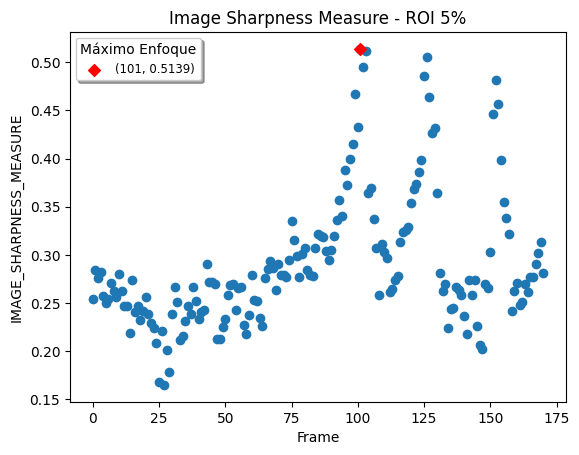

In [78]:
graficar_metricas_por_frames(ims_roi_5_df, x=ims_roi_5_max_frame, y=ims_roi_5_max_measure, title="Image Sharpness Measure - ROI 5%")

A continuación se muestra el frame donde se obtuvo la mejor métrica de enfoque

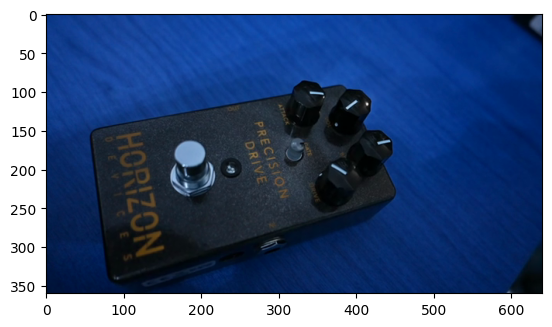

In [79]:
plt.imshow(ms_roi_5_frame)

La siguiente imagen corresponde al ROI utilizado sobre el frame que obtuvo la mejor métrica de enfoque.

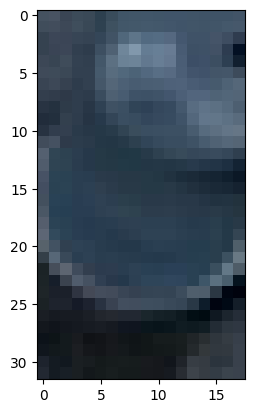

In [105]:
plt.imshow(imageQuality.__getROIFromImage__(image=ms_roi_5_frame, percentage=0.05))

### Métrica - Image Sharpness Measure - ROI 10%

A continuación se procesa el video utilizando la métrica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain`, trabajando sobre todo el frame (sin ROI).

El frame con mayor métrica de enfoque fue el número $150$, con un valor de mértica de $0.4314$.

A diferencia de los otros casos, el frame con la mejor métrica ***NO*** resultó ser aquel con un buen enfoque. Esto puede deberse a una combinación del ROI utilizado ($10\%$), lo cual indica que podría ***NO*** resultar conveniente utilizar ROI, por más que sus tiempos de ejecución sean menores que utilziar el frame completo.

| Métrica | ROI% | Mejor Frame | Mejor valor métrica | Tiempo de ejecución |
| --- | --- | --- | --- | --- |
| `Image Sharpness` | - | $91$ | $0.1038$ | $30.4$ segundos |
| `Image Sharpness` | $5\%$ | $101$ | $0.5139$ | $0.7$ segundos |
| `Image Sharpness` | $10\%$ | $150$ | $0.4314$ | $0.6$ segundos |

In [100]:
ims_roi_10_df, ims_roi_10_max_frame, ims_roi_10_max_measure, ms_roi_10_frame = obtener_métricas_de_video(path=video_path, roiPercentage=0.1, measure=QualityMeasure.IMAGE_SHARPNESS_MEASURE)

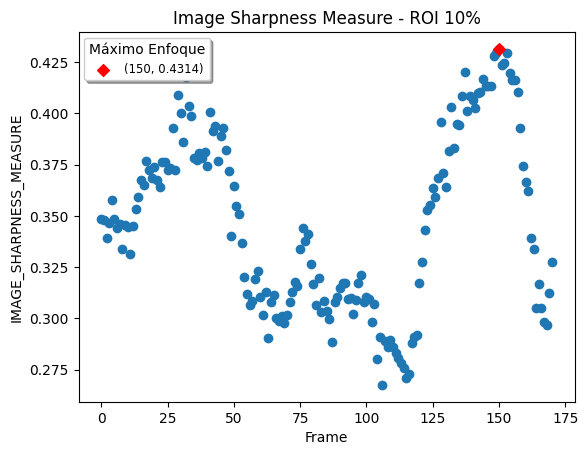

In [102]:
graficar_metricas_por_frames(ims_roi_10_df, x=ims_roi_10_max_frame, y=ims_roi_10_max_measure, title="Image Sharpness Measure - ROI 10%")

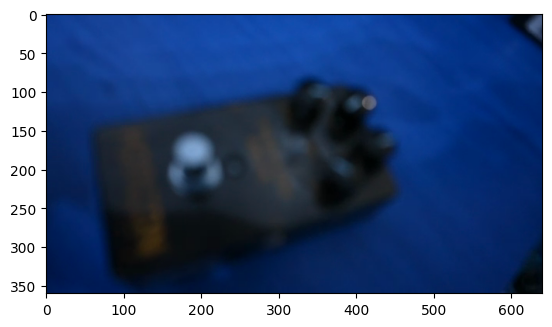

In [101]:
plt.imshow(ms_roi_10_frame)

La siguiente imagen corresponde al ROI utilizado sobre el frame que obtuvo la mejor métrica de enfoque.

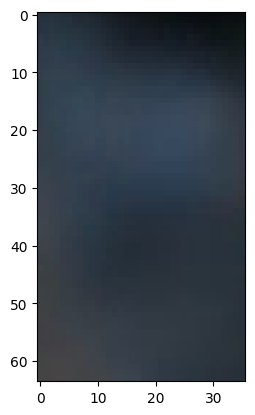

In [104]:
plt.imshow(imageQuality.__getROIFromImage__(image=ms_roi_10_frame, percentage=0.1))

### Métrica - Image Sharpness Measure - Comparación de resultados

Estos son los resultados obtenidos al aplicar la técnica definida en el paper `Image Sharpness Measure for Blurred Images in Frequency Domain` en cada frame del video de análisis:

| Métrica | ROI% | Mejor Frame | Mejor valor métrica | Tiempo de ejecución |
| --- | --- | --- | --- | --- |
| `Image Sharpness` | - | $91$ | $0.1038$ | $30.4$ segundos |
| `Image Sharpness` | $5\%$ | $101$ | $0.5139$ | $0.7$ segundos |
| `Image Sharpness` | $10\%$ | $150$ | $0.4314$ | $0.6$ segundos |

Al graficar el mejor frame de cada caso, se nota que para el caso en que NO se utiliza *ROI* como en el que se usa un *ROI* del $5\%$ el frame está enfocado, pero en el caso en que se usa un *ROI* de $10\%$ el frame está desenfocado.

Para analizar en mayor profundidad este caso, se grafican las evoluciones de las métricas frame a frame de cada caso,

- Lo primero que se nota en este gráfico es que aquellos casos donde se aplicaron *ROI* las métricas son *mayores* que aquellas correspondientes al caso donde NO se utilizó *ROI*.
- Luego, se nota que si bien el punto máximo es único en cada caso, existen otros frames con valores relativamente cercanos.

Se analizan los puntos máximos en cada caso:

- Caso sin *ROI*
    - Existe otro punto con métrica cercana al frame de máximo enfoque ($91$) que ronda al frame $112$ (aproximadamente).
    - Entre estos puntos, no hay valles, es decir, frames con métricas de menor magnitud.
    - Esto podría ser una medición correcta, ya que en el video hay varios segundos (entonces, varios frames) con "buen" enfoque, y estos frames están relativamente cerca.
- Caso con *ROI* del 5%
    - En este caso se notan $3$ picos altos, además del correspondiente al de máximo enfoque (frame $101$).
    - Entre todos estos puntos hay valles. En alguno de estos las métricas rondan con valores entre $0.5$ y $0.3$.
    - Además, el último pico con métrica alta (cercana a $0.5$) se encuentra luego del frame $150$, lo que corresponde a los instantes finales del video, donde la cámara se *desenfoca*.
- Caso con *ROI* del 10%
    - En este caso el punto de máximo enfoque está en el frame $150$, lo que corresponde a los instantes finales del video, donde la cámara se *desenfoca*.
    - Además, hay otro punto relativamente alto (respecto a la métrica) aproximadamente en el frame $30$, lo que corresponde a los instantes iniciales del video, donde la cámara se *desenfoca*.
    - Entre estos puntos, la métrica varia entre $0.4$ (valor máximo) y $0.3$.

***Conclusión***

La conclusión que podemos sacar de este experimento es que al ***NO*** aplicar *ROI* se obtienen los mejores valores, pero el tiempo de ejecución es mayor a los casos en donde si se aplica *ROI*.

Además, en caso de aplicar *ROI* no se debe "confiar" en la métrica final y en el frame con mejor métrica, sino que hay que analizar como evoluciona la métrica frame a frame, validando que no haya saltos grandes en las mediciones entre frames cuando no debería (es decir, comparándolo con el video, la fuente estos frames).

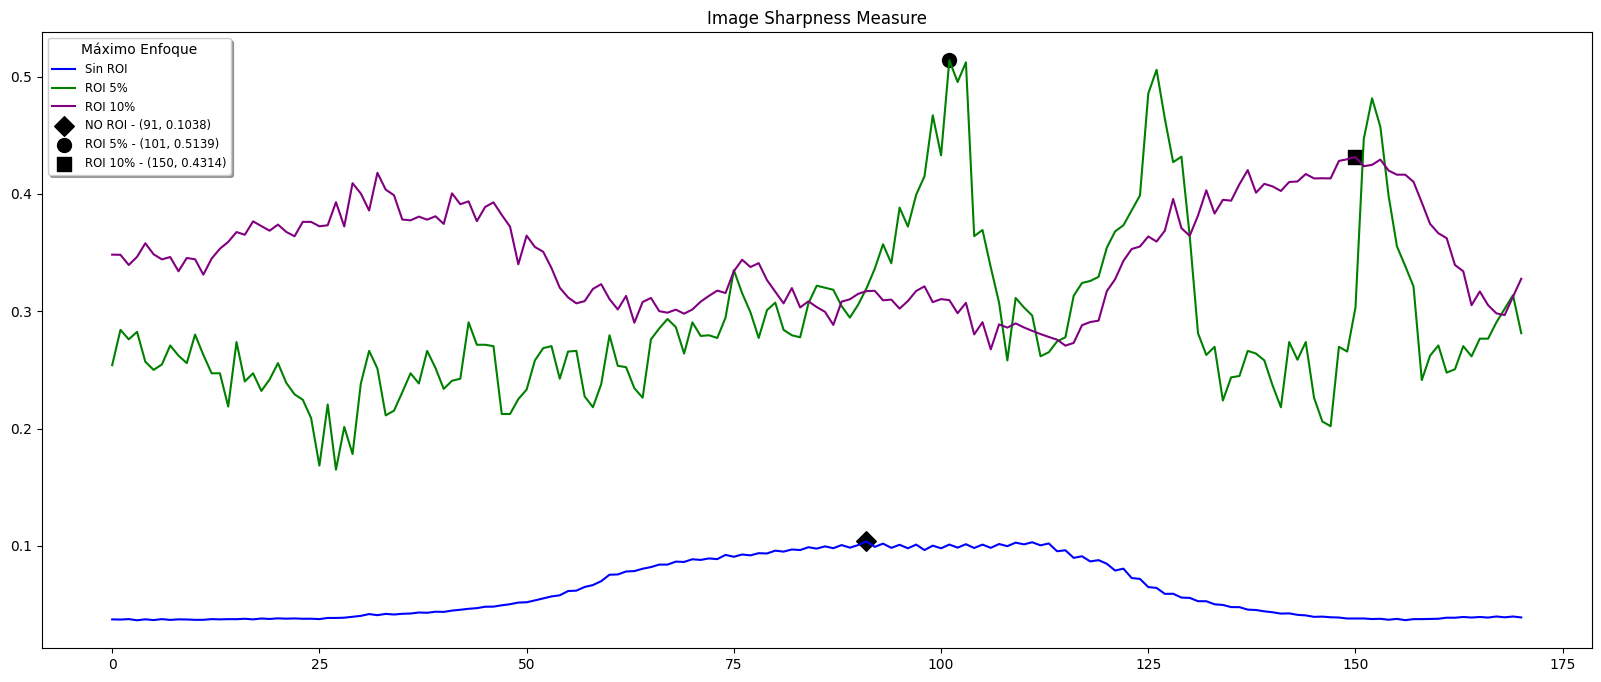

In [123]:

plt.figure(figsize=(20, 8))
plt.plot(ims_roi_100_df.iloc[:,0], ims_roi_100_df.iloc[:,1], c="blue", label=f"Sin ROI")
plt.plot(ims_roi_5_df.iloc[:,0], ims_roi_5_df.iloc[:,1], c="green", label=f"ROI 5%")
plt.plot(ims_roi_10_df.iloc[:,0], ims_roi_10_df.iloc[:,1], c="purple", label=f"ROI 10%")

plt.scatter(ims_roi_100_max_frame, ims_roi_100_max_measure, c="black", marker="D", s=100, label=f"NO ROI - {(int(ims_roi_100_max_frame), float(np.round(ims_roi_100_max_measure, 4)))}")
plt.scatter(ims_roi_5_max_frame, ims_roi_5_max_measure, c="black", marker="o", s=100, label=f"ROI 5% - {(int(ims_roi_5_max_frame), float(np.round(ims_roi_5_max_measure, 4)))}")
plt.scatter(ims_roi_10_max_frame, ims_roi_10_max_measure, c="black", marker="s", s=100, label=f"ROI 10% - {(int(ims_roi_10_max_frame), float(np.round(ims_roi_10_max_measure, 4)))}")

plt.title("Image Sharpness Measure")
plt.legend(loc='upper left', title="Máximo Enfoque", ncol=1, fontsize='small', frameon=True, shadow=True)

## Punto 2

### Métrica - Tenengrad Focus Measure

In [131]:
tenengrad_df, tenengrad_max_frame, tenengrad_max_measure, tenengrad_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, measure=QualityMeasure.TENENGRAD_FOCUS_MEASURE)

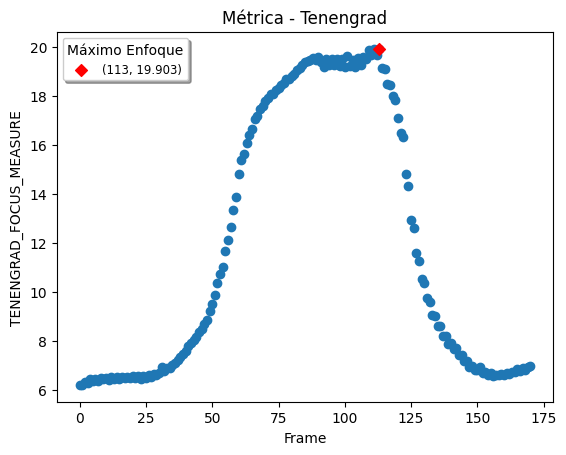

In [132]:
graficar_metricas_por_frames(tenengrad_df, x=tenengrad_max_frame, y=tenengrad_max_measure, title="Métrica - Tenengrad")

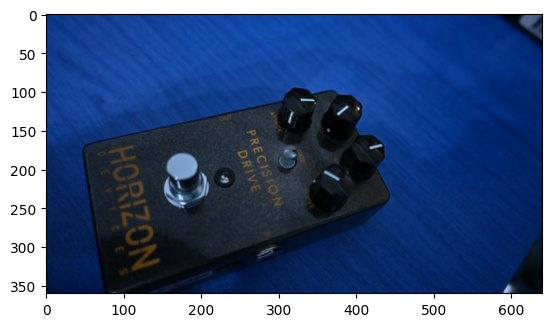

In [134]:
plt.imshow(tenengrad_frame)

### Métrica - Brenner Gradient Focus Measure

In [135]:
brenner_df, brenner_max_frame, brenner_max_measure, brenner_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, measure=QualityMeasure.BRENNER_GRADIENT_FOCUS_MEASURE)

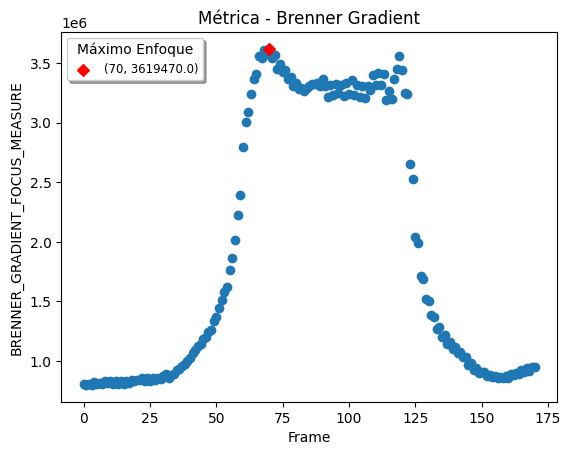

In [136]:
graficar_metricas_por_frames(brenner_df, x=brenner_max_frame, y=brenner_max_measure, title="Métrica - Brenner Gradient")

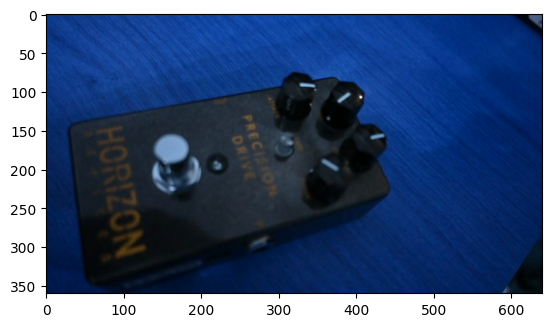

In [137]:
plt.imshow(brenner_frame)

### Métrica - Variance of Laplacian

In [138]:
vol_df, vol_max_frame, vol_max_measure, vol_frame = obtener_métricas_de_video(path=video_path, roiPercentage=1.0, measure=QualityMeasure.VARIANCE_OF_LAPLACIAN_FOCUS_MEASURE)

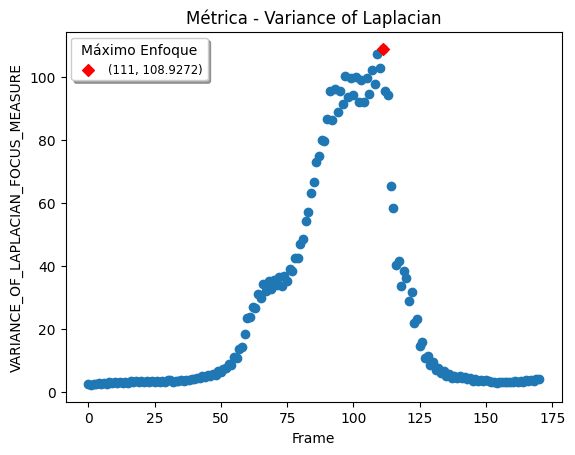

In [139]:
graficar_metricas_por_frames(vol_df, x=vol_max_frame, y=vol_max_measure, title="Métrica - Variance of Laplacian")

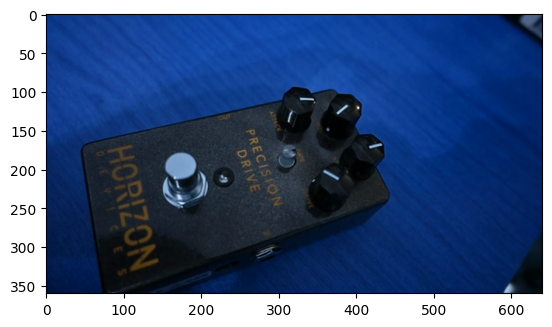

In [140]:
plt.imshow(vol_frame)